>>> Treinando Baseline
Epoch 01 | Tr MSE: 0.9442 | Val MSE: 0.8401
Epoch 02 | Tr MSE: 0.8454 | Val MSE: 0.8183
Epoch 03 | Tr MSE: 0.8216 | Val MSE: 0.8175
Epoch 04 | Tr MSE: 0.8158 | Val MSE: 0.8125
Epoch 05 | Tr MSE: 0.8143 | Val MSE: 0.8130
Epoch 06 | Tr MSE: 0.8125 | Val MSE: 0.8075
Epoch 07 | Tr MSE: 0.8130 | Val MSE: 0.8077
Epoch 08 | Tr MSE: 0.8123 | Val MSE: 0.8154
Epoch 09 | Tr MSE: 0.8121 | Val MSE: 0.8119
Epoch 10 | Tr MSE: 0.8126 | Val MSE: 0.8137
Epoch 11 | Tr MSE: 0.8123 | Val MSE: 0.8253
Epoch 12 | Tr MSE: 0.8117 | Val MSE: 0.8155
Epoch 13 | Tr MSE: 0.8116 | Val MSE: 0.8103
Epoch 14 | Tr MSE: 0.8121 | Val MSE: 0.8061
Epoch 15 | Tr MSE: 0.8106 | Val MSE: 0.8080
Epoch 16 | Tr MSE: 0.8109 | Val MSE: 0.8129
Epoch 17 | Tr MSE: 0.8107 | Val MSE: 0.8139
Epoch 18 | Tr MSE: 0.8116 | Val MSE: 0.8069
Epoch 19 | Tr MSE: 0.8104 | Val MSE: 0.8118
Epoch 20 | Tr MSE: 0.8104 | Val MSE: 0.8141
Epoch 21 | Tr MSE: 0.8113 | Val MSE: 0.8187
Epoch 22 | Tr MSE: 0.8111 | Val MSE: 0.8103
Epoch 23 

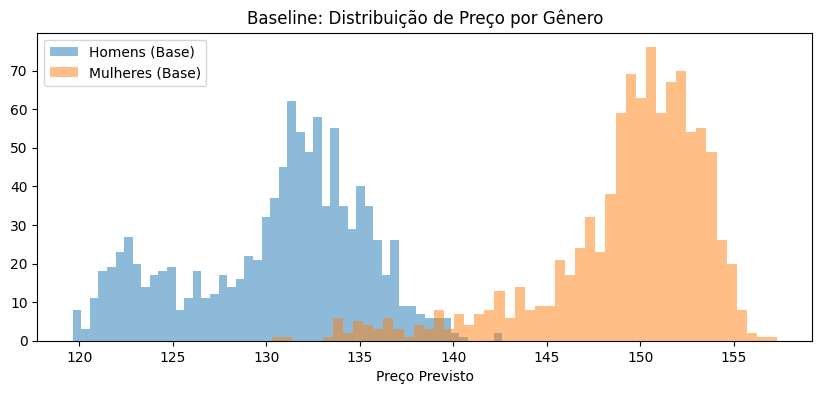

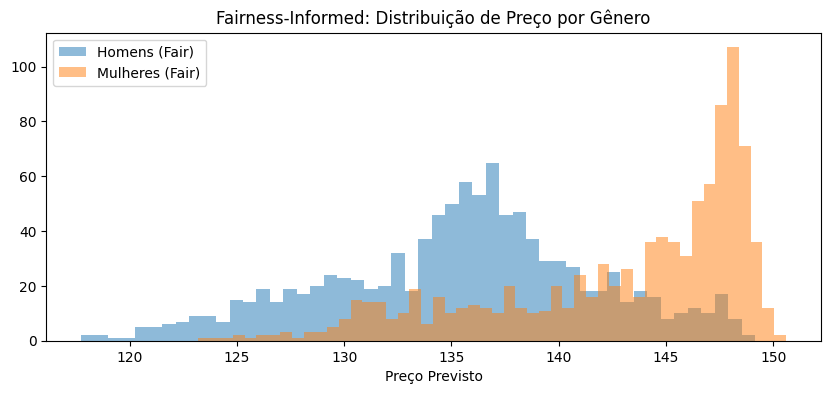

In [ ]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import random

# --- 0) Configurações gerais ---
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
random.seed(SEED)
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# --- 1) Simulação de dados ---
N_SAMPLES = 10_000

# 1.1) Variável sensível: gender (0=masc, 1=fem)
gender = np.random.binomial(1, 0.5, size=N_SAMPLES)

# 1.2) Altura, com distribuição distinta por gênero
height = np.where(
    gender == 0,
    np.random.normal(175, 7, size=N_SAMPLES),
    np.random.normal(162, 7, size=N_SAMPLES)
)

# 1.3) Idade e anos de habilitação
age = np.random.randint(18, 71, size=N_SAMPLES)
driving_years = np.random.randint(0, age - 17, size=N_SAMPLES)

# 1.4) Taxa de acidentes (causal via height/driving_years + correlação espúria c/ gender)
accident_rate = (
    0.01 * height
    - 0.02 * driving_years
    + np.random.normal(0, 1, size=N_SAMPLES)
    + 1.0 * gender
)

# 1.5) Preço do seguro
base_price = 100.0
k = 20.0
price = base_price + k * accident_rate + np.random.normal(0, 5, size=N_SAMPLES)

# --- 2) Split treino / teste e normalização só das contínuas ---
pct_train = 0.8
idx_split = int(N_SAMPLES * pct_train)

# trecores
gender_train, gender_test = gender[:idx_split], gender[idx_split:]
cont_train = np.stack([height, age, driving_years], axis=1)[:idx_split]
cont_test  = np.stack([height, age, driving_years], axis=1)[idx_split:]
y_train, y_test = price[:idx_split], price[idx_split:]

# normaliza só as contínuas
scaler_cont = StandardScaler().fit(cont_train)
cont_train_norm = scaler_cont.transform(cont_train)
cont_test_norm  = scaler_cont.transform(cont_test)

# reconstrói X mantendo gender binário
X_train_norm = np.column_stack([gender_train, cont_train_norm])
X_test_norm  = np.column_stack([gender_test,  cont_test_norm])

# target como array 2D
y_train = y_train.reshape(-1,1)
y_test  = y_test.reshape(-1,1)
scaler_y = StandardScaler().fit(y_train)
y_train_norm = scaler_y.transform(y_train)
y_test_norm  = scaler_y.transform(y_test)

# --- 3) Dataset e DataLoader ---
class InsuranceDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X).float()
        self.y = torch.from_numpy(y).float()
    def __len__(self):
        return len(self.y)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

batch_size = 64
train_ds = InsuranceDataset(X_train_norm, y_train_norm)
test_ds  = InsuranceDataset(X_test_norm,  y_test_norm)
train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
test_dl  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False)

# --- 4) Modelos MLP ---
class BaselineMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim=16):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )
    def forward(self, x):
        return self.net(x)

class FairnessMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim=16, gender_idx=0, lambda_reg=1.0):
        super().__init__()
        self.base = BaselineMLP(input_dim, hidden_dim).to(device)
        self.gender_idx = gender_idx
        self.lambda_reg = lambda_reg

    def forward(self, x):
        x_req = x.clone().detach().requires_grad_(True)
        y_pred = self.base(x_req)
        return y_pred, x_req

    def fairness_penalty(self, y_pred, x):
        grad = torch.autograd.grad(
            outputs=y_pred.sum(),
            inputs=x,
            create_graph=True
        )[0]  # (batch, input_dim)
        g_grad = grad[:, self.gender_idx]
        return self.lambda_reg * (g_grad ** 2).mean()

# --- 5) Treino / Validação ---
def train_model(model, train_loader, val_loader, epochs=30, lr=1e-3):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    for epoch in range(1, epochs+1):
        # treino
        model.train()
        mse_losses, pen_losses = [], []
        for Xb, yb in train_loader:
            Xb, yb = Xb.to(device), yb.to(device)
            optimizer.zero_grad()

            if isinstance(model, FairnessMLP):
                y_pred, X_req = model(Xb)
                mse = criterion(y_pred, yb)
                pen = model.fairness_penalty(y_pred, X_req)
                loss = mse + pen
                pen_losses.append(pen.item())
            else:
                y_pred = model(Xb)
                mse = criterion(y_pred, yb)
                loss = mse

            loss.backward()
            optimizer.step()
            mse_losses.append(mse.item())

        # validação
        model.eval()
        val_mse = []
        with torch.no_grad():
            for Xb, yb in val_loader:
                Xb, yb = Xb.to(device), yb.to(device)
                if isinstance(model, FairnessMLP):
                    y_pred, _ = model(Xb)
                else:
                    y_pred = model(Xb)
                val_mse.append(criterion(y_pred, yb).item())

        print(
            f"Epoch {epoch:02d} | "
            f"Tr MSE: {np.mean(mse_losses):.4f} | "
            + (f"Tr Pen: {np.mean(pen_losses):.4f} | " if pen_losses else "")
            + f"Val MSE: {np.mean(val_mse):.4f}"
        )

    return model

# --- 6) Instancia e treina ---
input_dim = X_train_norm.shape[1]
baseline_model = BaselineMLP(input_dim).to(device)
fair_model     = FairnessMLP(input_dim, lambda_reg=10.0).to(device)

print(">>> Treinando Baseline")
baseline_model = train_model(baseline_model, train_dl, test_dl, epochs=30, lr=1e-3)

print("\n>>> Treinando Fairness-Informed")
fair_model     = train_model(fair_model,     train_dl, test_dl, epochs=30, lr=1e-3)

# --- 7) Avaliação final usando o vetor raw de gender ---
def evaluate(model, loader, raw_genders):
    model.eval()
    preds, trues = [], []

    with torch.no_grad():
        for Xb, yb in loader:
            Xb, yb = Xb.to(device), yb.to(device)
            if isinstance(model, FairnessMLP):
                y_pred, _ = model(Xb)
            else:
                y_pred = model(Xb)
            preds.append(y_pred.cpu().numpy())
            trues.append(yb.cpu().numpy())

    preds = np.vstack(preds).flatten()
    trues = np.vstack(trues).flatten()
    # desnormaliza
    preds = scaler_y.inverse_transform(preds.reshape(-1,1)).flatten()
    trues = scaler_y.inverse_transform(trues.reshape(-1,1)).flatten()

    mse = mean_squared_error(trues, preds)
    # gender gap usando raw_genders
    gap = preds[raw_genders==1].mean() - preds[raw_genders==0].mean()
    return mse, gap, preds

# raw genders do teste
mse_base, gap_base, preds_base = evaluate(baseline_model, test_dl, gender_test)
mse_fair, gap_fair, preds_fair  = evaluate(fair_model,     test_dl, gender_test)

print(f"\nBaseline  → Test MSE: {mse_base:.4f}, Gender Gap: {gap_base:.2f}")
print(f"FairModel → Test MSE: {mse_fair:.4f}, Gender Gap: {gap_fair:.2f}")

# --- 8) Plots comparativos agora válidos ---
plt.figure(figsize=(10,4))
plt.hist(preds_base[gender_test==0], bins=50, alpha=0.5, label='Homens (Base)')
plt.hist(preds_base[gender_test==1], bins=50, alpha=0.5, label='Mulheres (Base)')
plt.title("Baseline: Distribuição de Preço por Gênero")
plt.xlabel("Preço Previsto")
plt.legend()
plt.show()

plt.figure(figsize=(10,4))
plt.hist(preds_fair[gender_test==0], bins=50, alpha=0.5, label='Homens (Fair)')
plt.hist(preds_fair[gender_test==1], bins=50, alpha=0.5, label='Mulheres (Fair)')
plt.title("Fairness-Informed: Distribuição de Preço por Gênero")
plt.xlabel("Preço Previsto")
plt.legend()
plt.show()


=== Baseline ===
Ep001 | TrMSE 1.155548 Pen 0.000000 | VaMSE 3.233666 Pen 0.000000
Ep002 | TrMSE 1.087030 Pen 0.000000 | VaMSE 3.119455 Pen 0.000000
Ep003 | TrMSE 1.029111 Pen 0.000000 | VaMSE 3.003875 Pen 0.000000
Ep004 | TrMSE 0.972218 Pen 0.000000 | VaMSE 2.885278 Pen 0.000000
Ep005 | TrMSE 0.910146 Pen 0.000000 | VaMSE 2.759476 Pen 0.000000
Ep006 | TrMSE 0.839587 Pen 0.000000 | VaMSE 2.622511 Pen 0.000000
Ep007 | TrMSE 0.761414 Pen 0.000000 | VaMSE 2.474359 Pen 0.000000
Ep008 | TrMSE 0.680203 Pen 0.000000 | VaMSE 2.319367 Pen 0.000000
Ep009 | TrMSE 0.602493 Pen 0.000000 | VaMSE 2.167605 Pen 0.000000
Ep010 | TrMSE 0.534432 Pen 0.000000 | VaMSE 2.030831 Pen 0.000000
Ep011 | TrMSE 0.479188 Pen 0.000000 | VaMSE 1.915767 Pen 0.000000
Ep012 | TrMSE 0.436025 Pen 0.000000 | VaMSE 1.822607 Pen 0.000000
Ep013 | TrMSE 0.401898 Pen 0.000000 | VaMSE 1.747797 Pen 0.000000
Ep014 | TrMSE 0.373680 Pen 0.000000 | VaMSE 1.686570 Pen 0.000000
Ep015 | TrMSE 0.349274 Pen 0.000000 | VaMSE 1.634309 Pen 0.

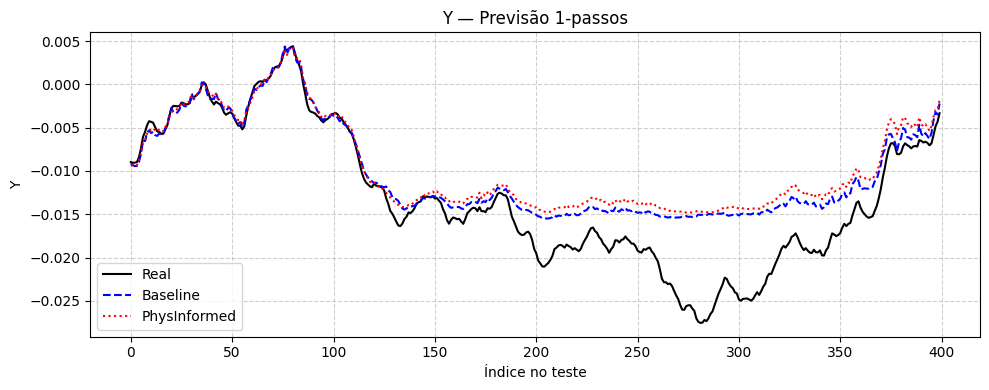

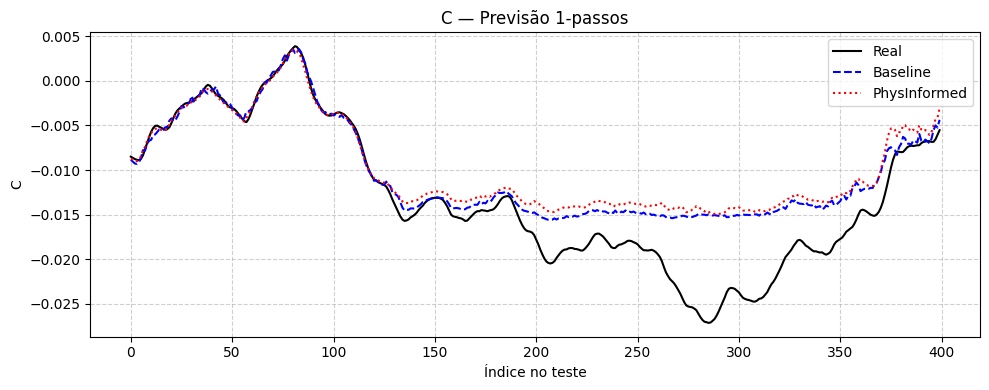

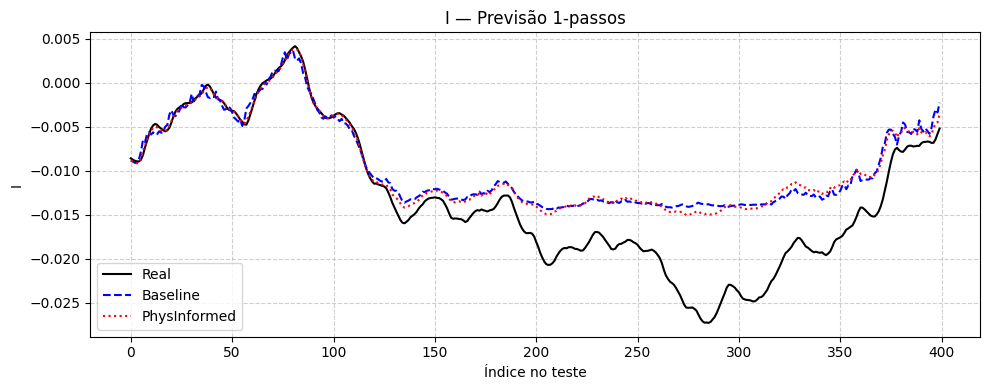

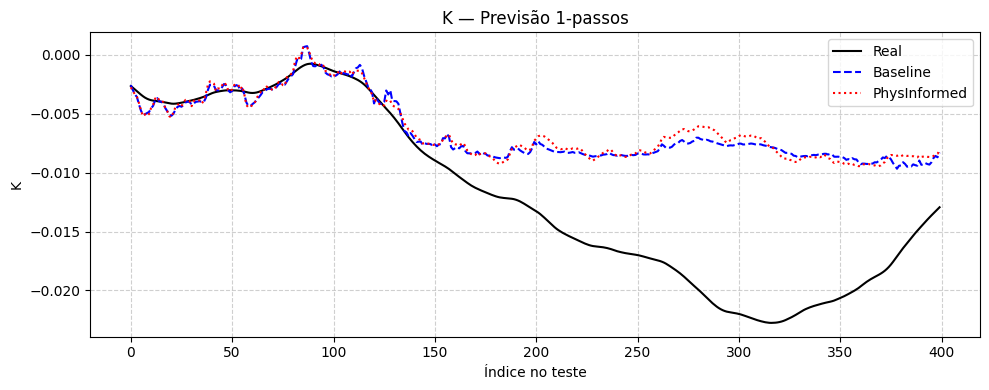

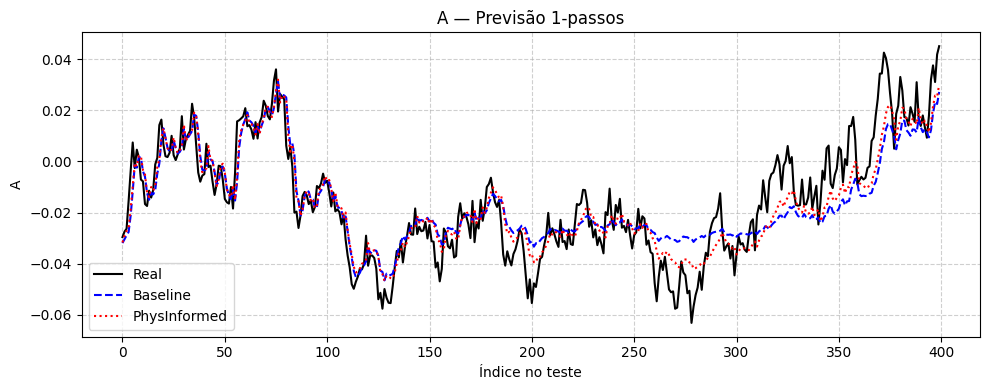

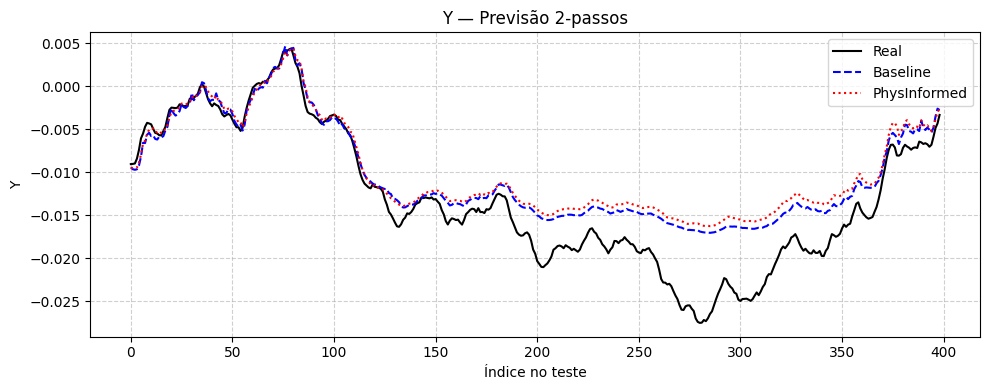

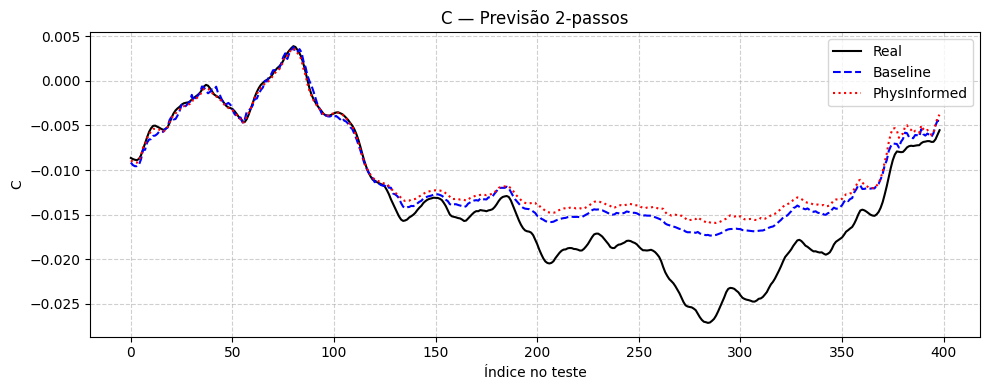

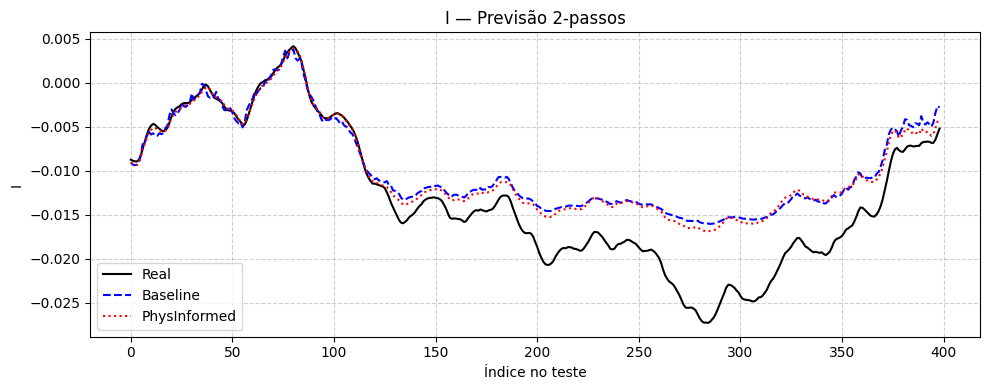

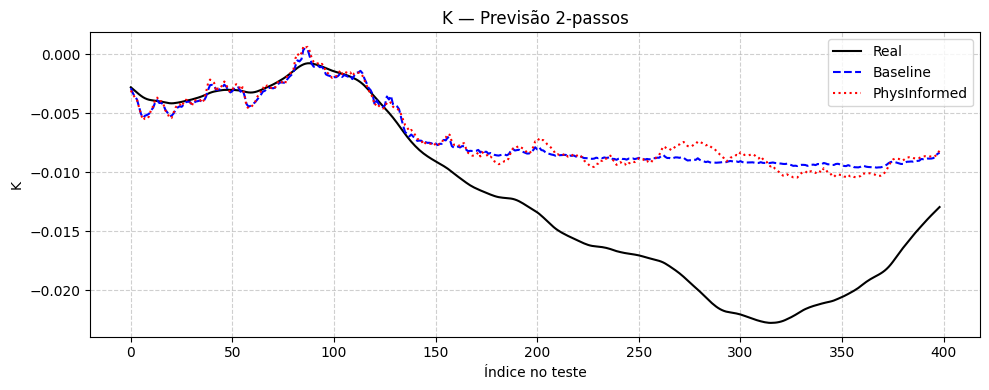

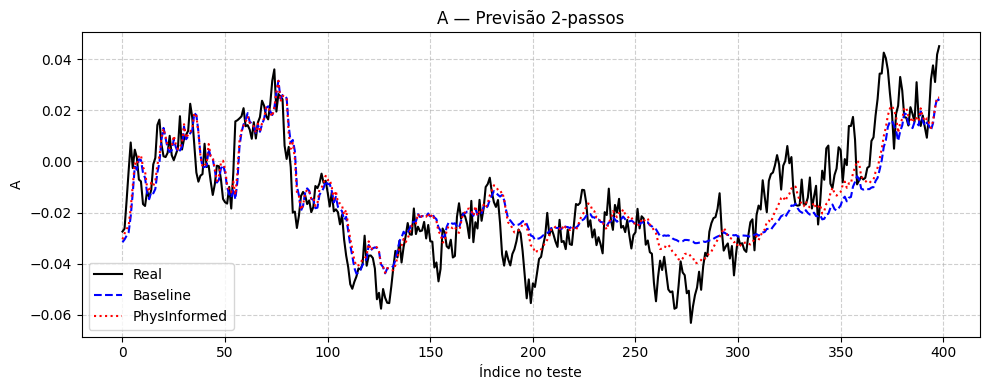

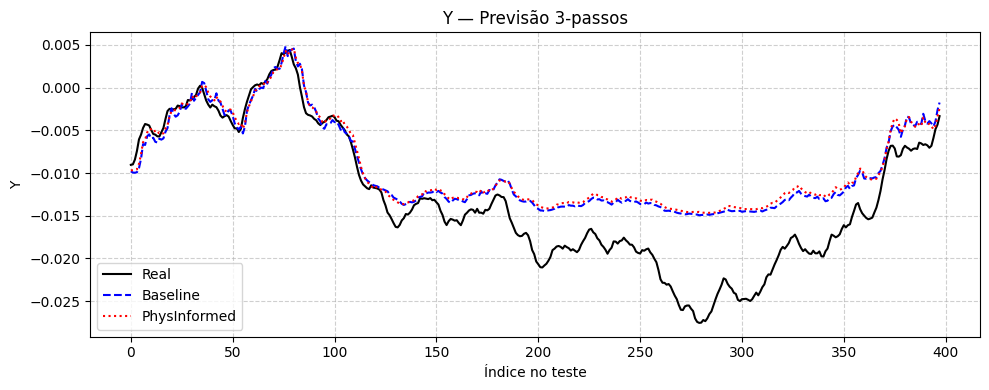

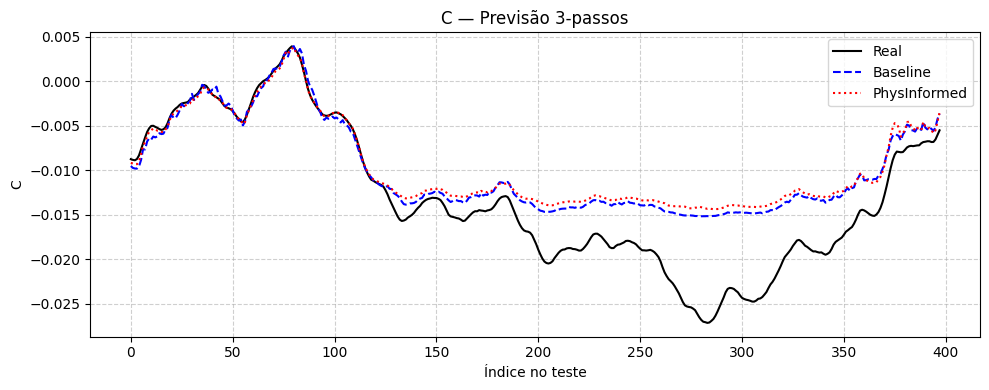

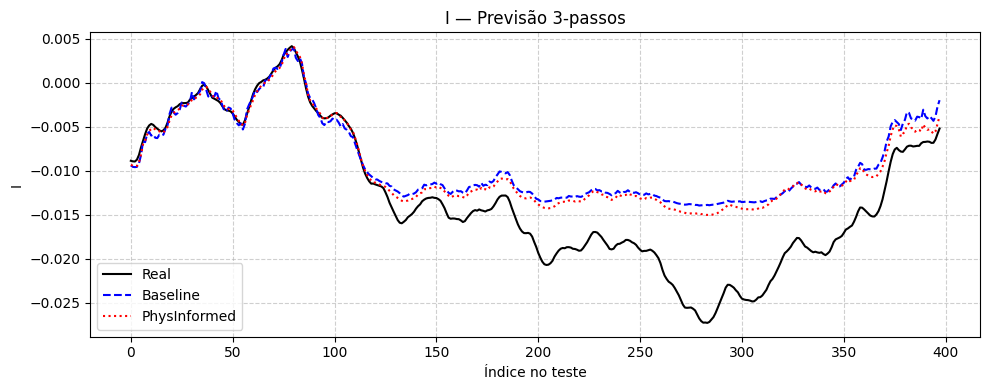

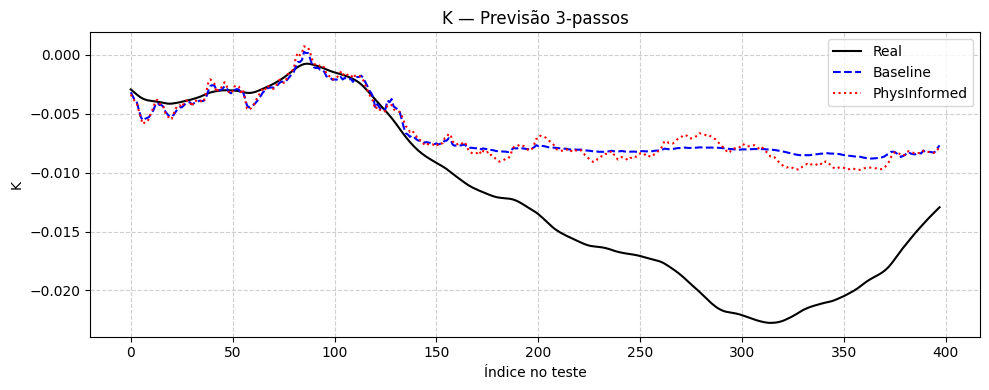

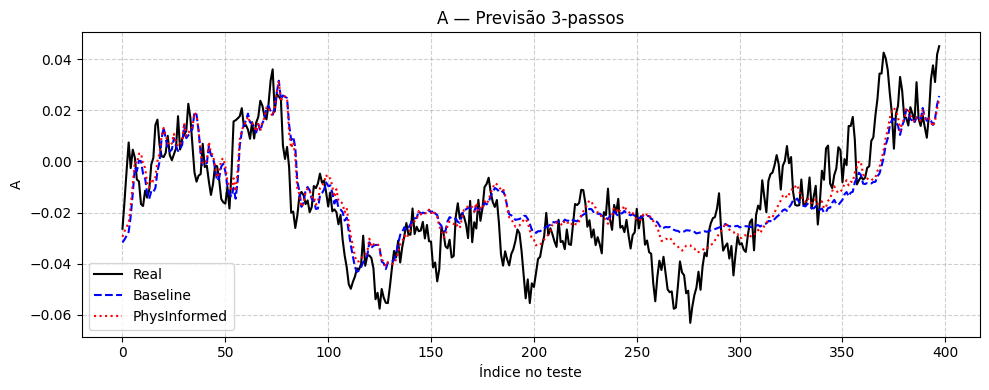

In [ ]:
import time
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# --- Configurações gerais ---
device = 'cuda' if torch.cuda.is_available() else 'cpu'
#np.random.seed(42)
#torch.manual_seed(42)

# --- 1) Modelo RBC-like log-linear ---
alpha_y, alpha_k, alpha_a = 0.8, 0.15, 0.05   # Y depende de Y, K e A
phi_c, phi_y = 0.7, 0.3                       # C depende de C e Y
phi_i, phi_yi = 0.6, 0.4                     # I depende de I e Y
delta = 0.025                                # depreciação de capital
rho = 0.95                                  # persistência do choque tecnológico
sigma_e = 0.007                             # volatilidade do choque

# Variáveis: [Y, C, I, K, A]
N = 5
A_mat = np.array([
    [alpha_y,      0.0,     0.0,     alpha_k, alpha_a],
    [phi_y,     phi_c,     0.0,       0.0,     0.0],
    [phi_yi,      0.0,   phi_i,       0.0,     0.0],
    [0.0,         0.0,     delta,   1-delta,   0.0],
    [0.0,         0.0,     0.0,       0.0,     rho]
])
B_vec = np.array([0.0, 0.0, 0.0, 0.0, 1.0])

def generate_rbc_series(length, seed=None):
    if seed is not None:
        np.random.seed(seed)
    X = np.zeros((length, N))
    for t in range(1, length):
        u_t = np.random.normal(scale=sigma_e)
        X[t] = A_mat.dot(X[t-1]) + B_vec * u_t
    return X

# --- 2) Extrair links causais (lag 1) ---
extracted_links = {j: [(i, -1) for i in range(N) if abs(A_mat[i,j])>1e-8] for j in range(N)}

# --- 3) Hiperparâmetros e dados ---
TOTAL_LEN, TRAIN_PCT, L, BATCH_SIZE = 2000, 0.8, 5, 64

data_full = generate_rbc_series(TOTAL_LEN)#, seed=123)
n_train   = int(TOTAL_LEN * TRAIN_PCT)
train_raw = data_full[:n_train]
test_raw  = data_full[n_train - L:]

scaler     = StandardScaler().fit(train_raw)
train_norm = scaler.transform(train_raw)
test_norm  = scaler.transform(test_raw)

# --- 4) Dataset / DataLoader ---
class TSset(Dataset):
    def __init__(self, arr, L):
        self.L = L
        self.X = torch.from_numpy(arr).float()
    def __len__(self):
        return len(self.X) - self.L
    def __getitem__(self, i):
        return self.X[i:i+self.L], self.X[i+self.L]

train_ds = TSset(train_norm, L)
test_ds  = TSset(test_norm,  L)
train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=False)
test_dl  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

# --- 5) Modelos ---
class BaselineLSTM(nn.Module):
    def __init__(self, N, hidden_size):
        super().__init__()
        self.lstm = nn.LSTM(input_size=N, hidden_size=hidden_size, batch_first=True)
        self.out  = nn.Linear(hidden_size, N)
    def forward(self, x):
        _, (h_n, _) = self.lstm(x)
        return self.out(h_n.squeeze(0))

class PhysicsInformedLSTM(nn.Module):
    def __init__(self, N, hidden_size, extracted_links, L, device):
        super().__init__()
        self.N = N; self.L = L; self.device = device
        self.base = BaselineLSTM(N, hidden_size).to(device)
        self.lambda_reg = 1e-2
        mask = torch.ones(L, N, N, dtype=torch.bool)
        for j, lk in extracted_links.items():
            for i, neg_tau in lk:
                tau = -neg_tau
                if 1 <= tau <= L:
                    mask[L-tau, i, j] = False
        self.register_buffer('mask_non_edge', mask)
    def forward(self, x):
        x_req = x.clone().detach().requires_grad_(True)
        return self.base(x_req), x_req
    def physics_penalty(self, y_pred, x):
        penalty = 0.0; B = y_pred.shape[0]
        for j in range(self.N):
            grad_j = torch.autograd.grad(outputs=y_pred[:,j].sum(), inputs=x, create_graph=True)[0]
            penalty += (grad_j**2 * self.mask_non_edge[:,:,j]).sum()
        return self.lambda_reg * penalty / B

# --- 6) Treino/Validação ---
def train_model(model, train_loader, val_loader, epochs, lr=1e-3):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    mse_loss = nn.MSELoss()
    for epoch in range(1, epochs+1):
        model.train(); tr_mse = tr_pen = cnt = 0
        for x,y in train_loader:
            x,y = x.to(device), y.to(device)
            opt.zero_grad()
            if isinstance(model, PhysicsInformedLSTM):
                y_pred, x_req = model(x)
                l_mse = mse_loss(y_pred, y)
                l_pen = model.physics_penalty(y_pred, x_req)
                loss = l_mse + l_pen; tr_pen += l_pen.item()
            else:
                y_pred = model(x); loss = mse_loss(y_pred, y)
            loss.backward(); opt.step()
            tr_mse += mse_loss(y_pred,y).item(); cnt += 1
        model.eval(); val_mse = val_pen = v_cnt = 0
        with torch.no_grad():
            for x,y in val_loader:
                x,y = x.to(device), y.to(device)
                if isinstance(model, PhysicsInformedLSTM):
                    with torch.enable_grad():
                        y_pred, x_req = model(x)
                        l_pen = model.physics_penalty(y_pred, x_req)
                    val_pen += l_pen.item()
                else:
                    y_pred = model(x)
                val_mse += mse_loss(y_pred,y).item(); v_cnt += 1
        print(f"Ep{epoch:03d} | TrMSE {tr_mse/cnt:.6f} Pen {tr_pen/cnt:.6f} | "
              f"VaMSE {val_mse/v_cnt:.6f} Pen {val_pen/v_cnt:.6f}")
    return model

# --- 7) Execução de treino ---
hidden = 8
baseline = BaselineLSTM(N, hidden).to(device)
pi_model = PhysicsInformedLSTM(N, hidden, extracted_links, L, device).to(device)
print("=== Baseline ===")
baseline = train_model(baseline, train_dl, test_dl, epochs=130)
print("\n=== Physics-Informed ===")
pi_model  = train_model(pi_model, train_dl, test_dl, epochs=130)

# --- 8) Forecast recursivo ---
def recursive_forecast(model, seq, steps):
    seq_np = seq.clone().cpu().numpy()
    forecasts = []
    cur = torch.tensor(seq_np, dtype=torch.float32).to(device)
    for _ in range(steps):
        inp = cur[-L:].unsqueeze(0)
        with torch.no_grad():
            out = model(inp)[0] if isinstance(model, PhysicsInformedLSTM) else model(inp)
            y_hat = out.squeeze(0)
        forecasts.append(y_hat.cpu().numpy())
        cur = torch.cat([cur, y_hat.unsqueeze(0)], dim=0)
    return np.array(forecasts)

# --- 9) Coleta e desnormaliza previsões ---
preds = {'Base':{h:[] for h in [1,2,3]}, 'Phys':{h:[] for h in [1,2,3]}}
test_len = len(test_ds)
for i in range(test_len):
    x_seq,_ = test_ds[i]
    base_fc = recursive_forecast(baseline, x_seq, 3)
    phys_fc = recursive_forecast(pi_model, x_seq, 3)
    for idx,h in enumerate([1,2,3]):
        preds['Base'][h].append(base_fc[idx])
        preds['Phys'][h].append(phys_fc[idx])
y_true = {}
for h in [1,2,3]:
    true = np.vstack([test_ds[i+h-1][1].numpy() for i in range(test_len-h+1)])
    y_true[h] = scaler.inverse_transform(true)
    for m in preds:
        arr = np.vstack(preds[m][h])[:len(y_true[h])]
        preds[m][h] = scaler.inverse_transform(arr)

# --- 10) Impressão de métricas com mais precisão ---
import math
for h in [1,2,3]:
    print(f"\n==== Horizonte {h} ====")
    for m in ['Base','Phys']:
        mse = mean_squared_error(y_true[h], preds[m][h])
        rmse = math.sqrt(mse)
        mae  = np.mean(np.abs(y_true[h] - preds[m][h]))
        print(f"{m:12s} MSE={mse:.6e} | RMSE={rmse:.6e} | MAE={mae:.6e}")

# --- 11) Plots comparativos ---
var_names = ['Y','C','I','K','A']
for h in [1,2,3]:
    t_idx = np.arange(len(y_true[h]))
    for i,var in enumerate(var_names):
        plt.figure(figsize=(10,4))
        plt.plot(t_idx, y_true[h][:,i], 'k-', label='Real')
        plt.plot(t_idx, preds['Base'][h][:,i], 'b--', label='Baseline')
        plt.plot(t_idx, preds['Phys'][h][:,i],  'r:', label='PhysInformed')
        plt.title(f"{var} — Previsão {h}-passos")
        plt.xlabel("Índice no teste")
        plt.ylabel(var)
        plt.legend(); plt.grid(linestyle='--', alpha=0.6)
        plt.tight_layout(); plt.show()


Lag escolhido por AIC: 5
=== Baseline ===
Ep001 | TrMSE 0.972093 | Pen 0.000000 | VaMSE 0.884688 | Pen 0.000000
Ep002 | TrMSE 0.890047 | Pen 0.000000 | VaMSE 0.810286 | Pen 0.000000
Ep003 | TrMSE 0.808338 | Pen 0.000000 | VaMSE 0.729986 | Pen 0.000000
Ep004 | TrMSE 0.720956 | Pen 0.000000 | VaMSE 0.644112 | Pen 0.000000
Ep005 | TrMSE 0.630433 | Pen 0.000000 | VaMSE 0.557840 | Pen 0.000000
Ep006 | TrMSE 0.543638 | Pen 0.000000 | VaMSE 0.478994 | Pen 0.000000
Ep007 | TrMSE 0.468687 | Pen 0.000000 | VaMSE 0.414032 | Pen 0.000000
Ep008 | TrMSE 0.409815 | Pen 0.000000 | VaMSE 0.364301 | Pen 0.000000
Ep009 | TrMSE 0.365749 | Pen 0.000000 | VaMSE 0.326899 | Pen 0.000000
Ep010 | TrMSE 0.332398 | Pen 0.000000 | VaMSE 0.297887 | Pen 0.000000
Ep011 | TrMSE 0.305778 | Pen 0.000000 | VaMSE 0.274146 | Pen 0.000000
Ep012 | TrMSE 0.283212 | Pen 0.000000 | VaMSE 0.253726 | Pen 0.000000
Ep013 | TrMSE 0.263274 | Pen 0.000000 | VaMSE 0.235571 | Pen 0.000000
Ep014 | TrMSE 0.245317 | Pen 0.000000 | VaMSE 0.

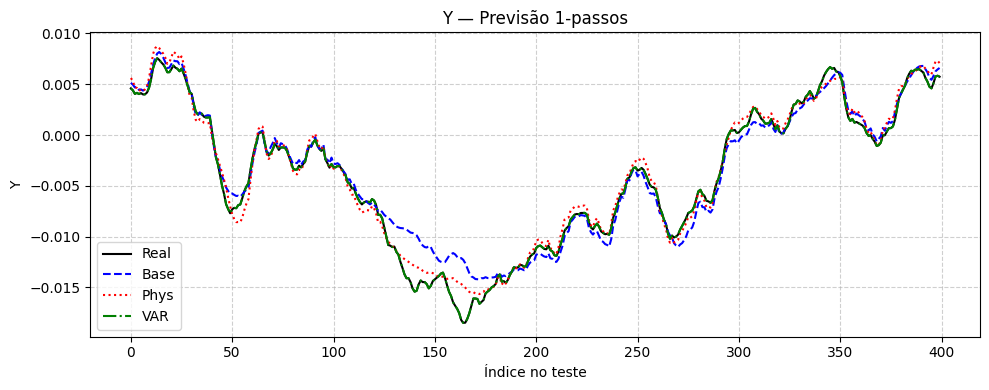

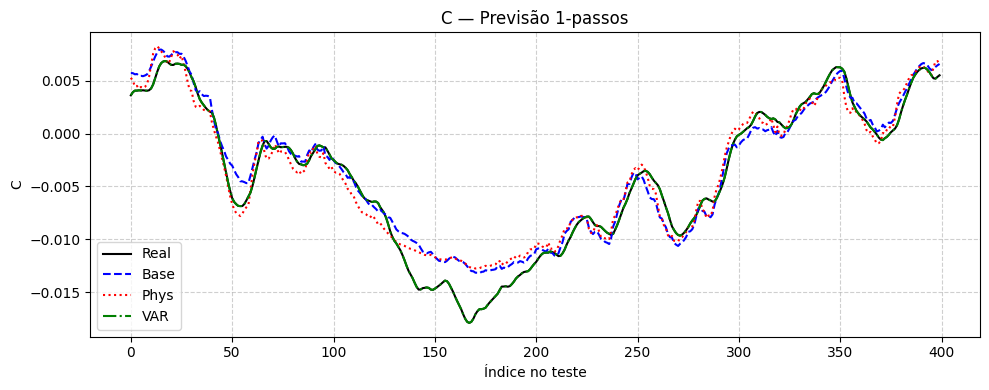

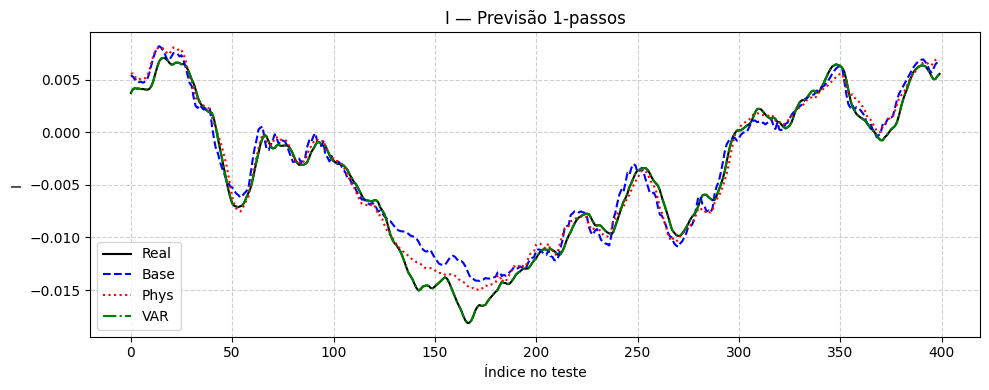

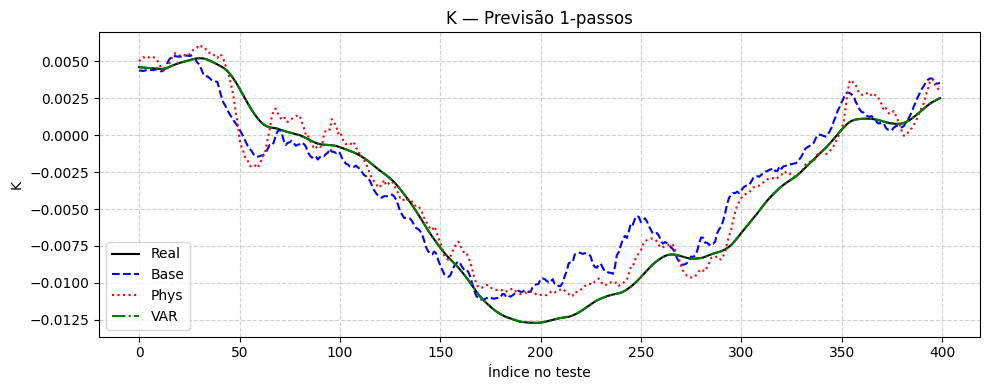

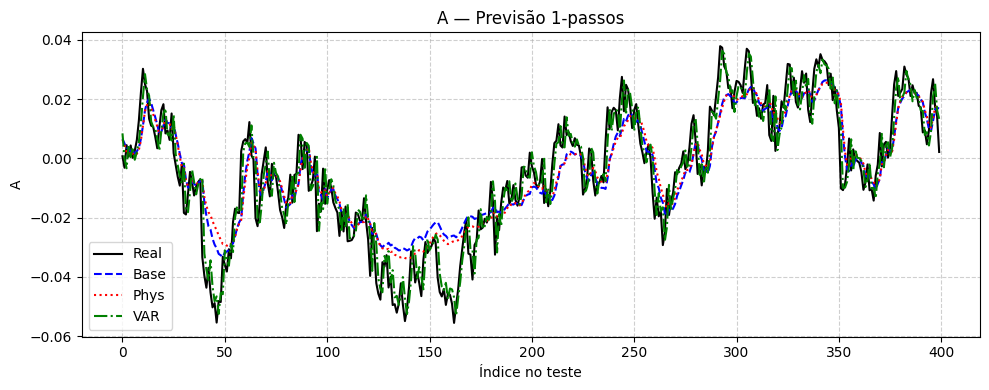

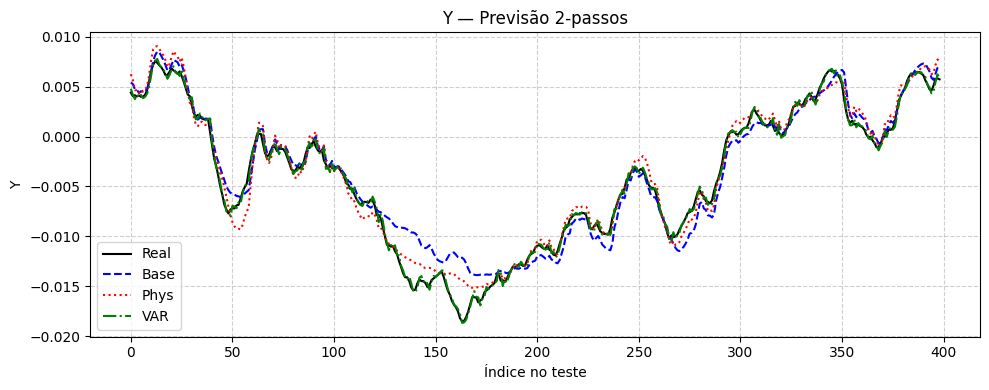

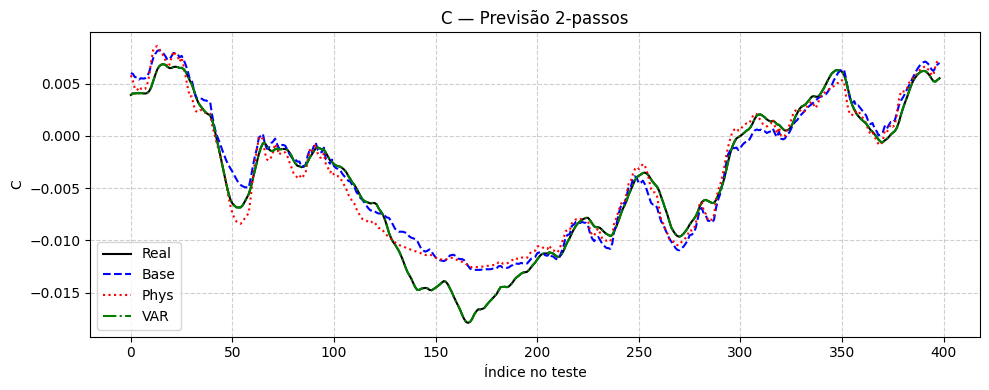

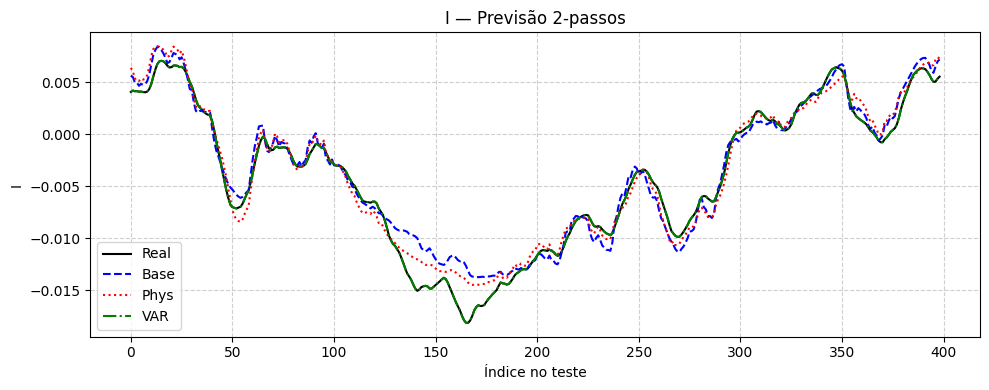

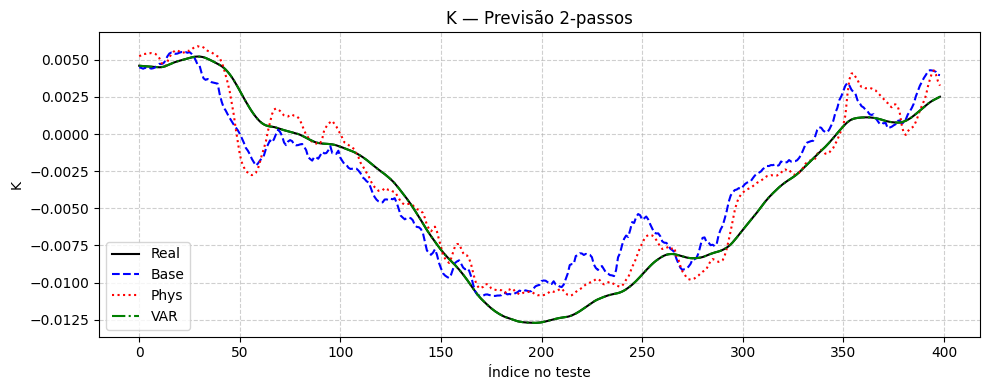

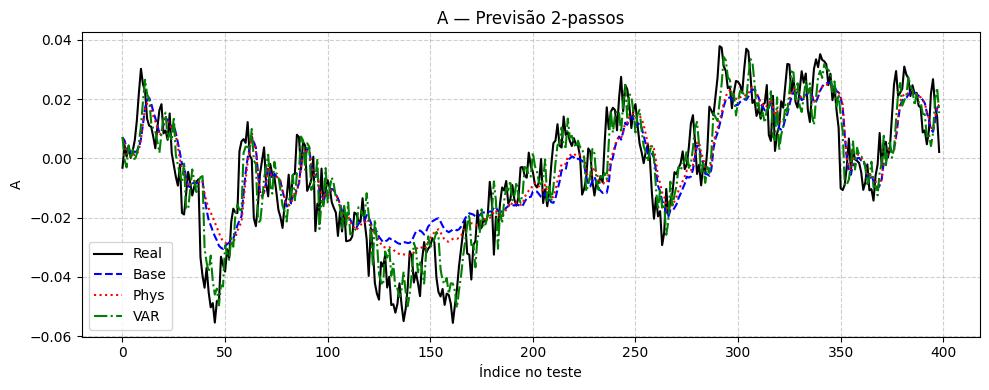

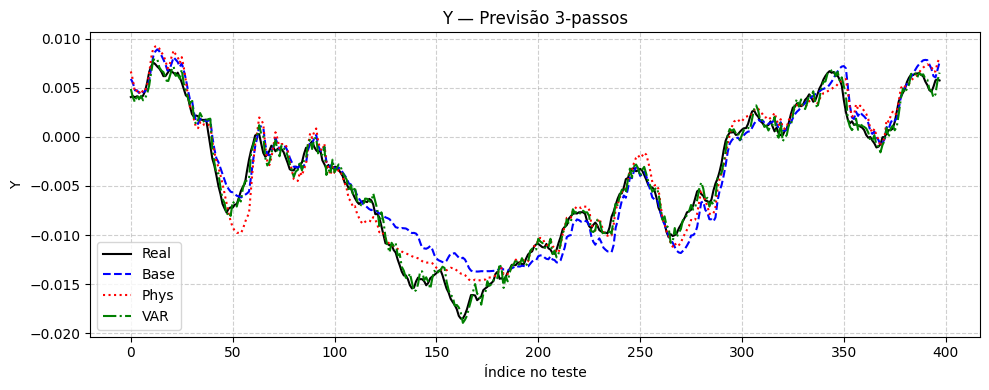

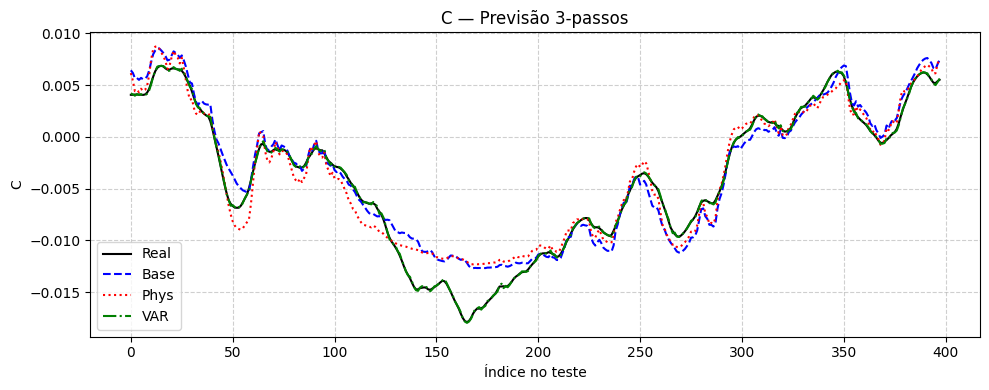

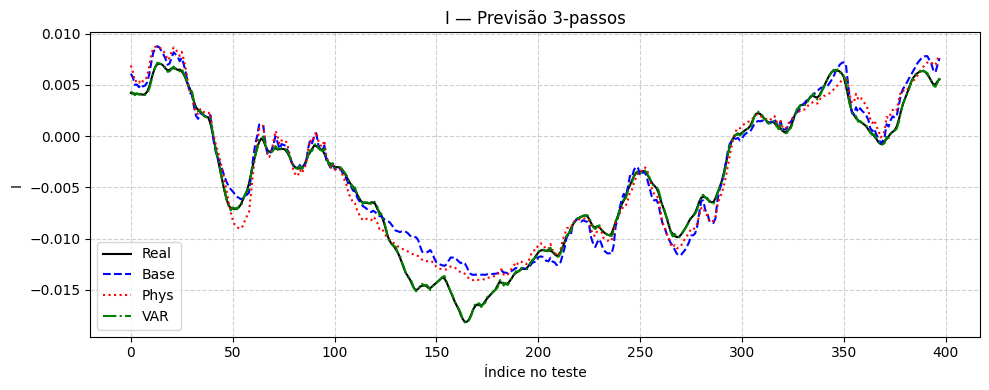

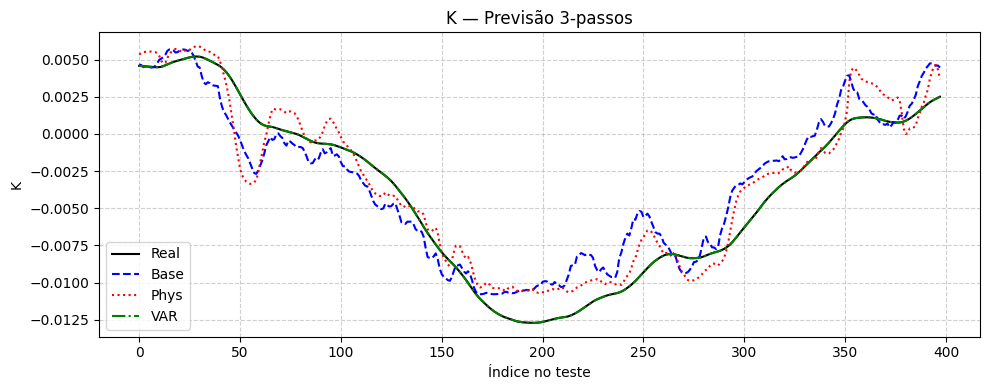

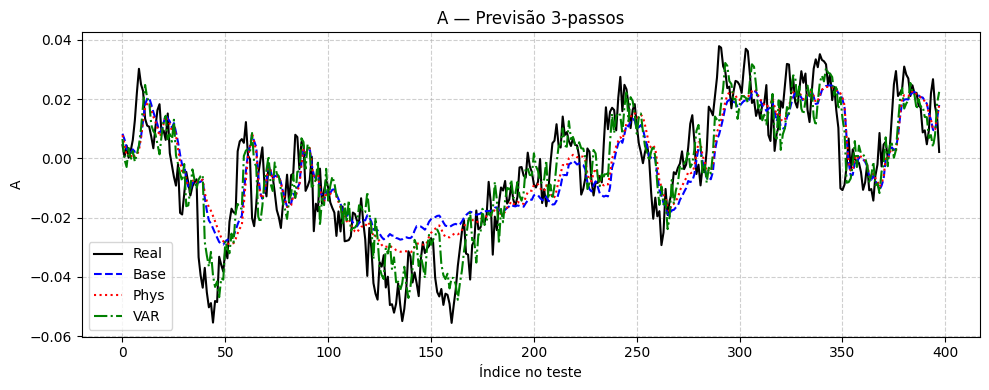

In [ ]:
import time
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
from statsmodels.tsa.api import VAR
import math

# --- Configurações gerais ---
device = 'cuda' if torch.cuda.is_available() else 'cpu'
np.random.seed(42)
torch.manual_seed(42)

# --- 1) Modelo RBC-like log-linear ---
alpha_y, alpha_k, alpha_a = 0.8, 0.15, 0.05   # Y depende de Y, K e A
phi_c, phi_y = 0.7, 0.3                       # C depende de C e Y
phi_i, phi_yi = 0.6, 0.4                     # I depende de I e Y
delta = 0.025                                # depreciação de capital
rho = 0.95                                  # persistência do choque tecnológico
sigma_e = 0.007                             # volatilidade do choque

# Variáveis: [Y, C, I, K, A]
N = 5
A_mat = np.array([
    [alpha_y,      0.0,     0.0,     alpha_k, alpha_a],
    [phi_y,     phi_c,     0.0,       0.0,     0.0],
    [phi_yi,      0.0,   phi_i,       0.0,     0.0],
    [0.0,         0.0,     delta,   1-delta,   0.0],
    [0.0,         0.0,     0.0,       0.0,     rho]
])
B_vec = np.array([0.0, 0.0, 0.0, 0.0, 1.0])

def generate_rbc_series(length, seed=None):
    if seed is not None:
        np.random.seed(seed)
    X = np.zeros((length, N))
    for t in range(1, length):
        u_t = np.random.normal(scale=sigma_e)
        X[t] = A_mat.dot(X[t-1]) + B_vec * u_t
    return X

# --- 2) Hiperparâmetros e dados ---
TOTAL_LEN, TRAIN_PCT, L, BATCH_SIZE = 2000, 0.8, 5, 64

data_full = generate_rbc_series(TOTAL_LEN, seed=123)
n_train   = int(TOTAL_LEN * TRAIN_PCT)
train_raw = data_full[:n_train]
test_raw  = data_full[n_train - L:]

# normaliza SÓ no treino
scaler     = StandardScaler().fit(train_raw)
train_norm = scaler.transform(train_raw)
test_norm  = scaler.transform(test_raw)

# --- 3) Estimar VAR e extrair ordem de defasagens ---
# Usamos treino completo para definir número de lags por AIC
var_model = VAR(train_norm)
max_lags = 10
lag_order = var_model.select_order(maxlags=max_lags).aic
var_res   = var_model.fit(lag_order)
print(f"Lag escolhido por AIC: {lag_order}")

# --- 4) Extrair links causais (lag 1) ---
extracted_links = {j: [(i, -1) for i in range(N) if abs(A_mat[i,j])>1e-8] for j in range(N)}

# --- 5) Dataset / DataLoader ---
class TSset(Dataset):
    def __init__(self, arr, L):
        self.L = L
        self.X = torch.from_numpy(arr).float()
    def __len__(self):
        return len(self.X) - self.L
    def __getitem__(self, i):
        return self.X[i:i+self.L], self.X[i+self.L]

train_ds = TSset(train_norm, L)
test_ds  = TSset(test_norm,  L)
train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=False)
test_dl  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

# --- 6) Modelos LSTM ---
class BaselineLSTM(nn.Module):
    def __init__(self, N, hidden_size):
        super().__init__()
        self.lstm = nn.LSTM(input_size=N, hidden_size=hidden_size, batch_first=True)
        self.out  = nn.Linear(hidden_size, N)
    def forward(self, x):
        _, (h_n, _) = self.lstm(x)
        return self.out(h_n.squeeze(0))

class PhysicsInformedLSTM(nn.Module):
    def __init__(self, N, hidden_size, extracted_links, L, device):
        super().__init__()
        self.N = N; self.L = L; self.device = device
        self.base = BaselineLSTM(N, hidden_size).to(device)
        self.lambda_reg = 1e-2
        mask = torch.ones(L, N, N, dtype=torch.bool)
        for j, lk in extracted_links.items():
            for i, neg_tau in lk:
                tau = -neg_tau
                if 1 <= tau <= L:
                    mask[L-tau, i, j] = False
        self.register_buffer('mask_non_edge', mask)
    def forward(self, x):
        x_req = x.clone().detach().requires_grad_(True)
        return self.base(x_req), x_req
    def physics_penalty(self, y_pred, x):
        penalty = 0.0; B = y_pred.shape[0]
        for j in range(self.N):
            grad_j = torch.autograd.grad(outputs=y_pred[:,j].sum(), inputs=x, create_graph=True)[0]
            penalty += (grad_j**2 * self.mask_non_edge[:,:,j]).sum()
        return self.lambda_reg * penalty / B

# --- 7) Função de treino ---
def train_model(model, train_loader, val_loader, epochs, lr=1e-3):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    mse_loss = nn.MSELoss()
    for epoch in range(1, epochs+1):
        model.train(); tr_mse = tr_pen = cnt = 0
        for x,y in train_loader:
            x,y = x.to(device), y.to(device)
            opt.zero_grad()
            if isinstance(model, PhysicsInformedLSTM):
                y_pred, x_req = model(x)
                l_mse = mse_loss(y_pred, y)
                l_pen = model.physics_penalty(y_pred, x_req)
                loss = l_mse + l_pen; tr_pen += l_pen.item()
            else:
                y_pred = model(x); loss = mse_loss(y_pred, y)
            loss.backward(); opt.step()
            tr_mse += mse_loss(y_pred,y).item(); cnt += 1
        model.eval(); val_mse = val_pen = v_cnt = 0
        with torch.no_grad():
            for x,y in val_loader:
                x,y = x.to(device), y.to(device)
                if isinstance(model, PhysicsInformedLSTM):
                    with torch.enable_grad():
                        y_pred, x_req = model(x)
                        l_pen = model.physics_penalty(y_pred, x_req)
                    val_pen += l_pen.item()
                else:
                    y_pred = model(x)
                val_mse += mse_loss(y_pred,y).item(); v_cnt += 1
        print(f"Ep{epoch:03d} | TrMSE {tr_mse/cnt:.6f} | Pen {tr_pen/cnt:.6f} | "
              f"VaMSE {val_mse/v_cnt:.6f} | Pen {val_pen/v_cnt:.6f}")
    return model

# --- 8) Treino LSTMs ---
hidden = 8
baseline = BaselineLSTM(N, hidden).to(device)
pi_model = PhysicsInformedLSTM(N, hidden, extracted_links, L, device).to(device)
print("=== Baseline ===")
baseline = train_model(baseline, train_dl, test_dl, epochs=30)
print("\n=== Phys-Informed ===")
pi_model = train_model(pi_model, train_dl, test_dl, epochs=30)

# --- 9) Forecast recursivo LSTM ---
def recursive_forecast(model, seq, steps):
    seq_np = seq.clone().cpu().numpy()
    forecasts = []
    cur = torch.tensor(seq_np, dtype=torch.float32).to(device)
    for _ in range(steps):
        inp = cur[-L:].unsqueeze(0)
        with torch.no_grad():
            out = model(inp)[0] if isinstance(model, PhysicsInformedLSTM) else model(inp)
            y_hat = out.squeeze(0)
        forecasts.append(y_hat.cpu().numpy())
        cur = torch.cat([cur, y_hat.unsqueeze(0)], dim=0)
    return np.array(forecasts)

# --- 10) Forecast VAR ---
def var_forecast(window, steps):
    # window: array shape (p, N)
    fc = var_res.forecast(window[-lag_order:], steps)
    return np.array(fc)

# --- 11) Coleta previsões e desnormaliza ---
preds = {'Base':{h:[] for h in [1,2,3]},
         'Phys':{h:[] for h in [1,2,3]},
         'VAR':{h:[] for h in [1,2,3]}}
test_len = len(test_ds)
for i in range(test_len):
    x_seq,_ = test_ds[i]
    base_fc = recursive_forecast(baseline, x_seq, 3)
    phys_fc = recursive_forecast(pi_model, x_seq, 3)
    win_np  = x_seq.clone().cpu().numpy()
    var_fc  = var_forecast(win_np, 3)
    for idx,h in enumerate([1,2,3]):
        preds['Base'][h].append(base_fc[idx])
        preds['Phys'][h].append(phys_fc[idx])
        preds['VAR'][h].append(var_fc[idx])

# desnormaliza
y_true = {}
for h in [1,2,3]:
    true = np.vstack([test_ds[i+h-1][1].numpy() for i in range(test_len-h+1)])
    y_true[h] = scaler.inverse_transform(true)
    for m in preds:
        arr = np.vstack(preds[m][h])[:len(y_true[h])]
        preds[m][h] = scaler.inverse_transform(arr)

# --- 12) Métricas ---
for h in [1,2,3]:
    print(f"\n==== Horizonte {h} ====")
    for m in ['Base','Phys','VAR']:
        mse  = mean_squared_error(y_true[h], preds[m][h])
        rmse = math.sqrt(mse)
        mae  = np.mean(np.abs(y_true[h] - preds[m][h]))
        print(f"{m:12s} MSE={mse:.6e} | RMSE={rmse:.6e} | MAE={mae:.6e}")

# --- 13) Plots comparativos ---
var_names = ['Y','C','I','K','A']
colors = {'Base':'b--', 'Phys':'r:', 'VAR':'g-.'}
for h in [1,2,3]:
    t_idx = np.arange(len(y_true[h]))
    for i,var in enumerate(var_names):
        plt.figure(figsize=(10,4))
        plt.plot(t_idx, y_true[h][:,i], 'k-', label='Real')
        for m in ['Base','Phys','VAR']:
            plt.plot(t_idx, preds[m][h][:,i], colors[m], label=m)
        plt.title(f"{var} — Previsão {h}-passos")
        plt.xlabel("Índice no teste")
        plt.ylabel(var)
        plt.legend(); plt.grid(linestyle='--', alpha=0.6)
        plt.tight_layout(); plt.show()


Dados transformados (log-diff), shape: (312, 3)
Lag escolhido por AIC: 4
Treinando Baseline LSTM...
Ep01 | TrLoss=0.9562 | ValLoss=2.3782
Ep02 | TrLoss=0.8503 | ValLoss=2.4181
Ep03 | TrLoss=0.7990 | ValLoss=2.4199
Ep04 | TrLoss=0.7447 | ValLoss=2.5027
Ep05 | TrLoss=0.7113 | ValLoss=2.6816
Ep06 | TrLoss=0.6913 | ValLoss=2.4703
Ep07 | TrLoss=0.7277 | ValLoss=2.5422
Ep08 | TrLoss=0.6461 | ValLoss=2.5695
Ep09 | TrLoss=0.6663 | ValLoss=2.6576
Ep10 | TrLoss=0.6025 | ValLoss=2.6475
Ep11 | TrLoss=0.5655 | ValLoss=2.6072
Ep12 | TrLoss=0.5367 | ValLoss=2.5628
Ep13 | TrLoss=0.5028 | ValLoss=2.6727
Ep14 | TrLoss=0.4620 | ValLoss=2.7025
Ep15 | TrLoss=0.4049 | ValLoss=2.7520
Ep16 | TrLoss=0.3864 | ValLoss=2.6735
Ep17 | TrLoss=0.3416 | ValLoss=3.0019
Ep18 | TrLoss=0.3064 | ValLoss=2.6537
Ep19 | TrLoss=0.2774 | ValLoss=3.0457
Ep20 | TrLoss=0.2683 | ValLoss=2.7477
Ep21 | TrLoss=0.3003 | ValLoss=3.1318
Ep22 | TrLoss=0.2608 | ValLoss=2.7352
Ep23 | TrLoss=0.2288 | ValLoss=2.9958
Ep24 | TrLoss=0.1923 | Val

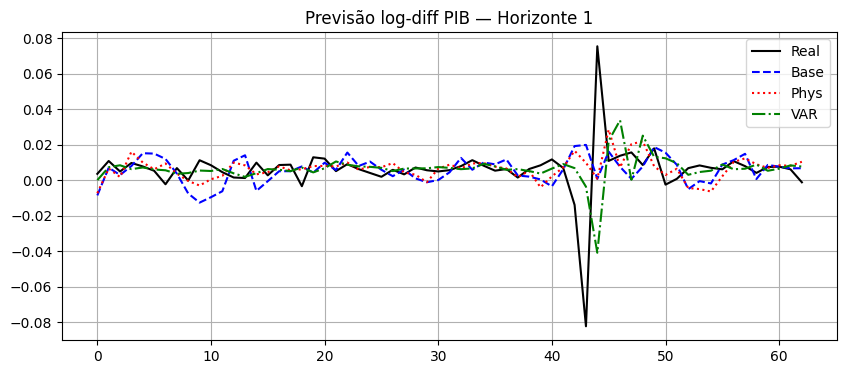


Horizonte 2
Base: MSE=1.3130e-03
Phys: MSE=1.0663e-03
VAR: MSE=8.1034e-04


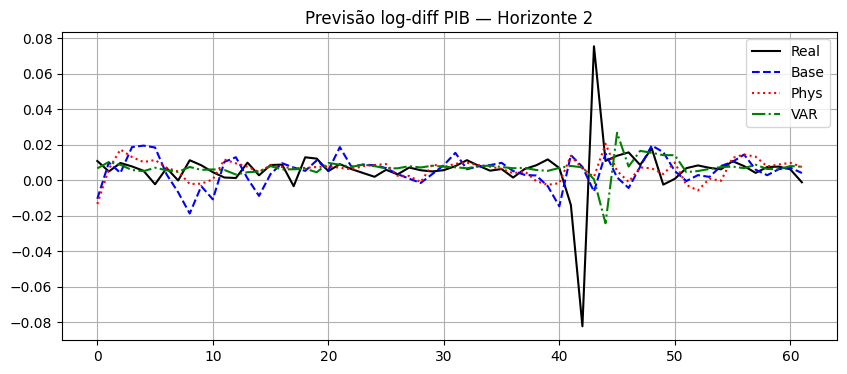


Horizonte 3
Base: MSE=1.3177e-03
Phys: MSE=1.0098e-03
VAR: MSE=7.1633e-04


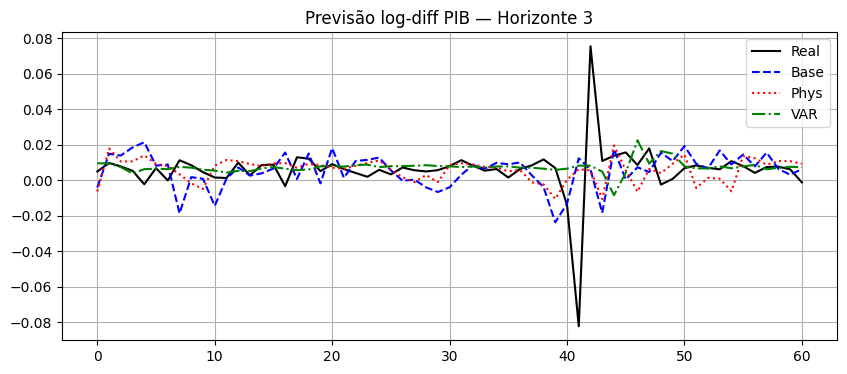

In [ ]:
import time
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
from statsmodels.tsa.api import VAR
import pandas_datareader.data as pdr
import datetime
import math

# --- Configurações gerais ---
device = 'cuda' if torch.cuda.is_available() else 'cpu'
np.random.seed(42)
torch.manual_seed(42)

# --- 1) Obtenção de dados empíricos (FRED) ---
start = datetime.datetime(1947, 1, 1)
end   = datetime.datetime.today()
symbols = ['GDPC1', 'PCECC96', 'GPDIC1']  # PIB real, consumo real e investimento real

df_fred = pdr.DataReader(symbols, 'fred', start, end).dropna()
if df_fred.index.freq is None:
    df_fred = df_fred.asfreq('QS').ffill().bfill()

# Transformação para log-diferenças (crescimento)
df_log  = np.log(df_fred)
df_diff = df_log.diff().dropna()
print(f"Dados transformados (log-diff), shape: {df_diff.shape}")

data_full = df_diff.values
N = data_full.shape[1]

# --- 2) Split e normalização ---
TOTAL_LEN, TRAIN_PCT = len(data_full), 0.8
L, BATCH_SIZE = 8, 32
epochs, lr = 50, 1e-2
n_train = int(TOTAL_LEN * TRAIN_PCT)
train_raw = data_full[:n_train]
test_raw  = data_full[n_train - L:]

scaler     = StandardScaler().fit(train_raw)
train_norm = scaler.transform(train_raw)
test_norm  = scaler.transform(test_raw)

# --- 3) Ajuste de VAR empírico ---
var_model = VAR(train_norm)
lag_order = var_model.select_order(maxlags=10).aic
var_res   = var_model.fit(lag_order)
print(f"Lag escolhido por AIC: {lag_order}")
threshold = 1e-4
extracted_links = {
    j: [(i, -l) for l in range(1, lag_order+1) for i in range(N)
        if abs(var_res.coefs[l-1, i, j]) > threshold]
    for j in range(N)
}
history_norm = np.vstack([train_norm, test_norm[L:]])

# --- 4) Dataset / DataLoader ---
class TSset(Dataset):
    def __init__(self, arr, L):
        self.L = L
        self.X = torch.from_numpy(arr).float()
    def __len__(self):
        return len(self.X) - self.L
    def __getitem__(self, i):
        return self.X[i:i+self.L], self.X[i+self.L]

train_ds = TSset(train_norm, L)
test_ds  = TSset(test_norm,  L)
train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
test_dl  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

# --- 5) Modelos LSTM ---
hidden_size = 64
class BaselineLSTM(nn.Module):
    def __init__(self, N, hidden_size):
        super().__init__()
        self.lstm = nn.LSTM(input_size=N, hidden_size=hidden_size,
                            num_layers=2, batch_first=True, dropout=0.2)
        self.out  = nn.Linear(hidden_size, N)
    def forward(self, x):
        _, (h_n, _) = self.lstm(x)
        return self.out(h_n[-1])

class PhysicsInformedLSTM(nn.Module):
    def __init__(self, N, hidden_size, links, L, device):
        super().__init__()
        self.N, self.L = N, L
        self.base = BaselineLSTM(N, hidden_size).to(device)
        self.lambda_reg = 1e-2
        mask = torch.ones(L, N, N, dtype=torch.bool)
        for j, lk in links.items():
            for i, neg_tau in lk:
                tau = -neg_tau
                if 1 <= tau <= L:
                    mask[L-tau, i, j] = False
        self.register_buffer('mask_non_edge', mask)
    def forward(self, x):
        x_req = x.clone().detach().requires_grad_(True)
        y_pred = self.base(x_req)
        return y_pred, x_req
    def physics_penalty(self, y_pred, x):
        penalty = 0.0
        for j in range(self.N):
            grad_j = torch.autograd.grad(outputs=y_pred[:,j].sum(),
                                         inputs=x, create_graph=True)[0]
            penalty += (grad_j**2 * self.mask_non_edge[:,:,j]).sum()
        return self.lambda_reg * penalty / y_pred.shape[0]

# --- 6) Treino e validação ---
def train_model(model, train_loader, val_loader):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    for ep in range(1, epochs+1):
        model.train(); tr_loss=0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            opt.zero_grad()
            if isinstance(model, PhysicsInformedLSTM):
                y_hat, x_req = model(x)
                loss = nn.MSELoss()(y_hat, y) + model.physics_penalty(y_hat, x_req)
            else:
                y_hat = model(x)
                loss = nn.MSELoss()(y_hat, y)
            loss.backward(); nn.utils.clip_grad_norm_(model.parameters(),1.0)
            opt.step(); tr_loss += loss.item()
        model.eval(); val_loss=0
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                y_hat = model(x)[0] if isinstance(model, PhysicsInformedLSTM) else model(x)
                val_loss += nn.MSELoss()(y_hat, y).item()
        print(f"Ep{ep:02d} | TrLoss={tr_loss/len(train_loader):.4f} | ValLoss={val_loss/len(val_loader):.4f}")
    return model

baseline = BaselineLSTM(N, hidden_size).to(device)
pi_model = PhysicsInformedLSTM(N, hidden_size, extracted_links, L, device).to(device)
print("Treinando Baseline LSTM...")
baseline = train_model(baseline, train_dl, test_dl)
print("Treinando Physics-Informed LSTM...")
pi_model = train_model(pi_model, train_dl, test_dl)

# --- 7) Previsões recursivas com ajuste de dimensões ---
def recursive_forecast(model, seq, steps):
    arr = seq.clone().cpu().numpy()
    if arr.ndim == 3:
        arr = arr.squeeze(0)  # remove batch dim se presente
    cur = torch.tensor(arr, dtype=torch.float32).to(device)
    out = []
    for _ in range(steps):
        inp = cur[-L:].unsqueeze(0)
        with torch.no_grad():
            if isinstance(model, PhysicsInformedLSTM):
                y_hat, _ = model(inp)
            else:
                y_hat = model(inp)
        y_np = y_hat.squeeze(0).cpu().numpy()
        out.append(y_np)
        new_t = torch.tensor(y_np, dtype=torch.float32).to(device).unsqueeze(0)
        cur = torch.cat([cur, new_t], dim=0)
    return np.array(out)

def var_forecast_global(idx, steps):
    win = history_norm[idx-lag_order:idx]
    return var_res.forecast(win, steps)

# --- 8) Coleta e avaliação ---
horizons=[1,2,3]
preds={m:{h:[] for h in horizons} for m in ['Base','Phys','VAR']}
t_len = len(test_ds)
for i in range(t_len):
    seq, _ = test_ds[i]
    base_f = recursive_forecast(baseline, seq, max(horizons))
    phys_f = recursive_forecast(pi_model, seq, max(horizons))
    var_f  = var_forecast_global(n_train+i, max(horizons))
    for idx, h in enumerate(horizons):
        preds['Base'][h].append(base_f[idx])
        preds['Phys'][h].append(phys_f[idx])
        preds['VAR'][h].append(var_f[idx])

var_names = df_diff.columns.tolist()
colors = {'Base':'b--','Phys':'r:','VAR':'g-.'}
for h in horizons:
    y_t = np.vstack([test_ds[i+h-1][1].numpy() for i in range(t_len-h+1)])
    y_true = scaler.inverse_transform(y_t)
    print(f"\nHorizonte {h}")
    for m in ['Base','Phys','VAR']:
        arr = np.vstack(preds[m][h])[:len(y_true)]
        pred = scaler.inverse_transform(arr)
        mse = mean_squared_error(y_true, pred)
        print(f"{m}: MSE={mse:.4e}")
    t = np.arange(len(y_true))
    plt.figure(figsize=(10,4))
    plt.plot(t, y_true[:,0], 'k-', label='Real')
    for m in ['Base','Phys','VAR']:
        arr = np.vstack(preds[m][h])[:len(y_true)]
        plt.plot(t, scaler.inverse_transform(arr)[:,0], colors[m], label=m)
    plt.title(f"Previsão log-diff PIB — Horizonte {h}")
    plt.legend(); plt.grid(True)
    plt.show()
